# 1 Installing the YOLOv8 Environment

To start off with YOLOv8 we first clone the YOLOv8 repository and install dependencies. This will set up our programming environment to be ready to running object detection training and inference commands.

In [1]:
# Clone repository
!git clone https://github.com/ultralytics/ultralytics

# Navigate to the cloned directory
%cd ultralytics

# Install the package in editable mode for development
!pip install -e .

C:\Users\CP1\Documents\GitHub\Itemized-Billing\ultralytics


fatal: destination path 'ultralytics' already exists and is not an empty directory.


Obtaining file:///C:/Users/CP1/Documents/GitHub/Itemized-Billing/ultralytics
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.165
    Uninstalling ultralytics-8.0.165:
      Successfully uninstalled ultralytics-8.0.165
  Running setup.py develop for ultralytics


# 2 Import Libraries

In [2]:
import torch
print('torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))
from ultralytics import YOLO

import yaml
import glob
from IPython.display import Image, display
from IPython.core.magic import register_line_cell_magic

torch 1.13.1+cu116 _CudaDeviceProperties(name='NVIDIA GeForce RTX 3090', major=8, minor=6, total_memory=24575MB, multi_processor_count=82)


In [3]:
%cd ..

# Open and read the YAML file
with open('config.yaml', 'r') as file:
    yaml_data = yaml.safe_load(file)

yaml_data

C:\Users\CP1\Documents\GitHub\Itemized-Billing


{'path': 'C:/Users/CP1/Documents/GitHub/Itemized-Billing/HB-yolo-1.1',
 'train': 'train.txt',
 'val': 'valid.txt',
 'nc': 1,
 'names': ['table']}

In [4]:
# Define number of classes based on YAML
with open('config.yaml', 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

print(f'Number of class: {num_classes}')

Number of class: 1


In [6]:
import os

current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: C:\Users\CP1\Documents\GitHub\Itemized-Billing


# 3 Train YOLOv8

In [7]:
model = YOLO('yolov8s.yaml')  # build a new model from scratch

results = model.train(data='config.yaml', epochs=50, workers=2)  # train the model


                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

# 4 Evaluate the model

In [13]:
results.results_dict

{'metrics/precision(B)': 0.9985087421385683,
 'metrics/recall(B)': 1.0,
 'metrics/mAP50(B)': 0.995,
 'metrics/mAP50-95(B)': 0.9663622023494376,
 'fitness': 0.9692259821144938}

In [23]:
results.confusion_matrix

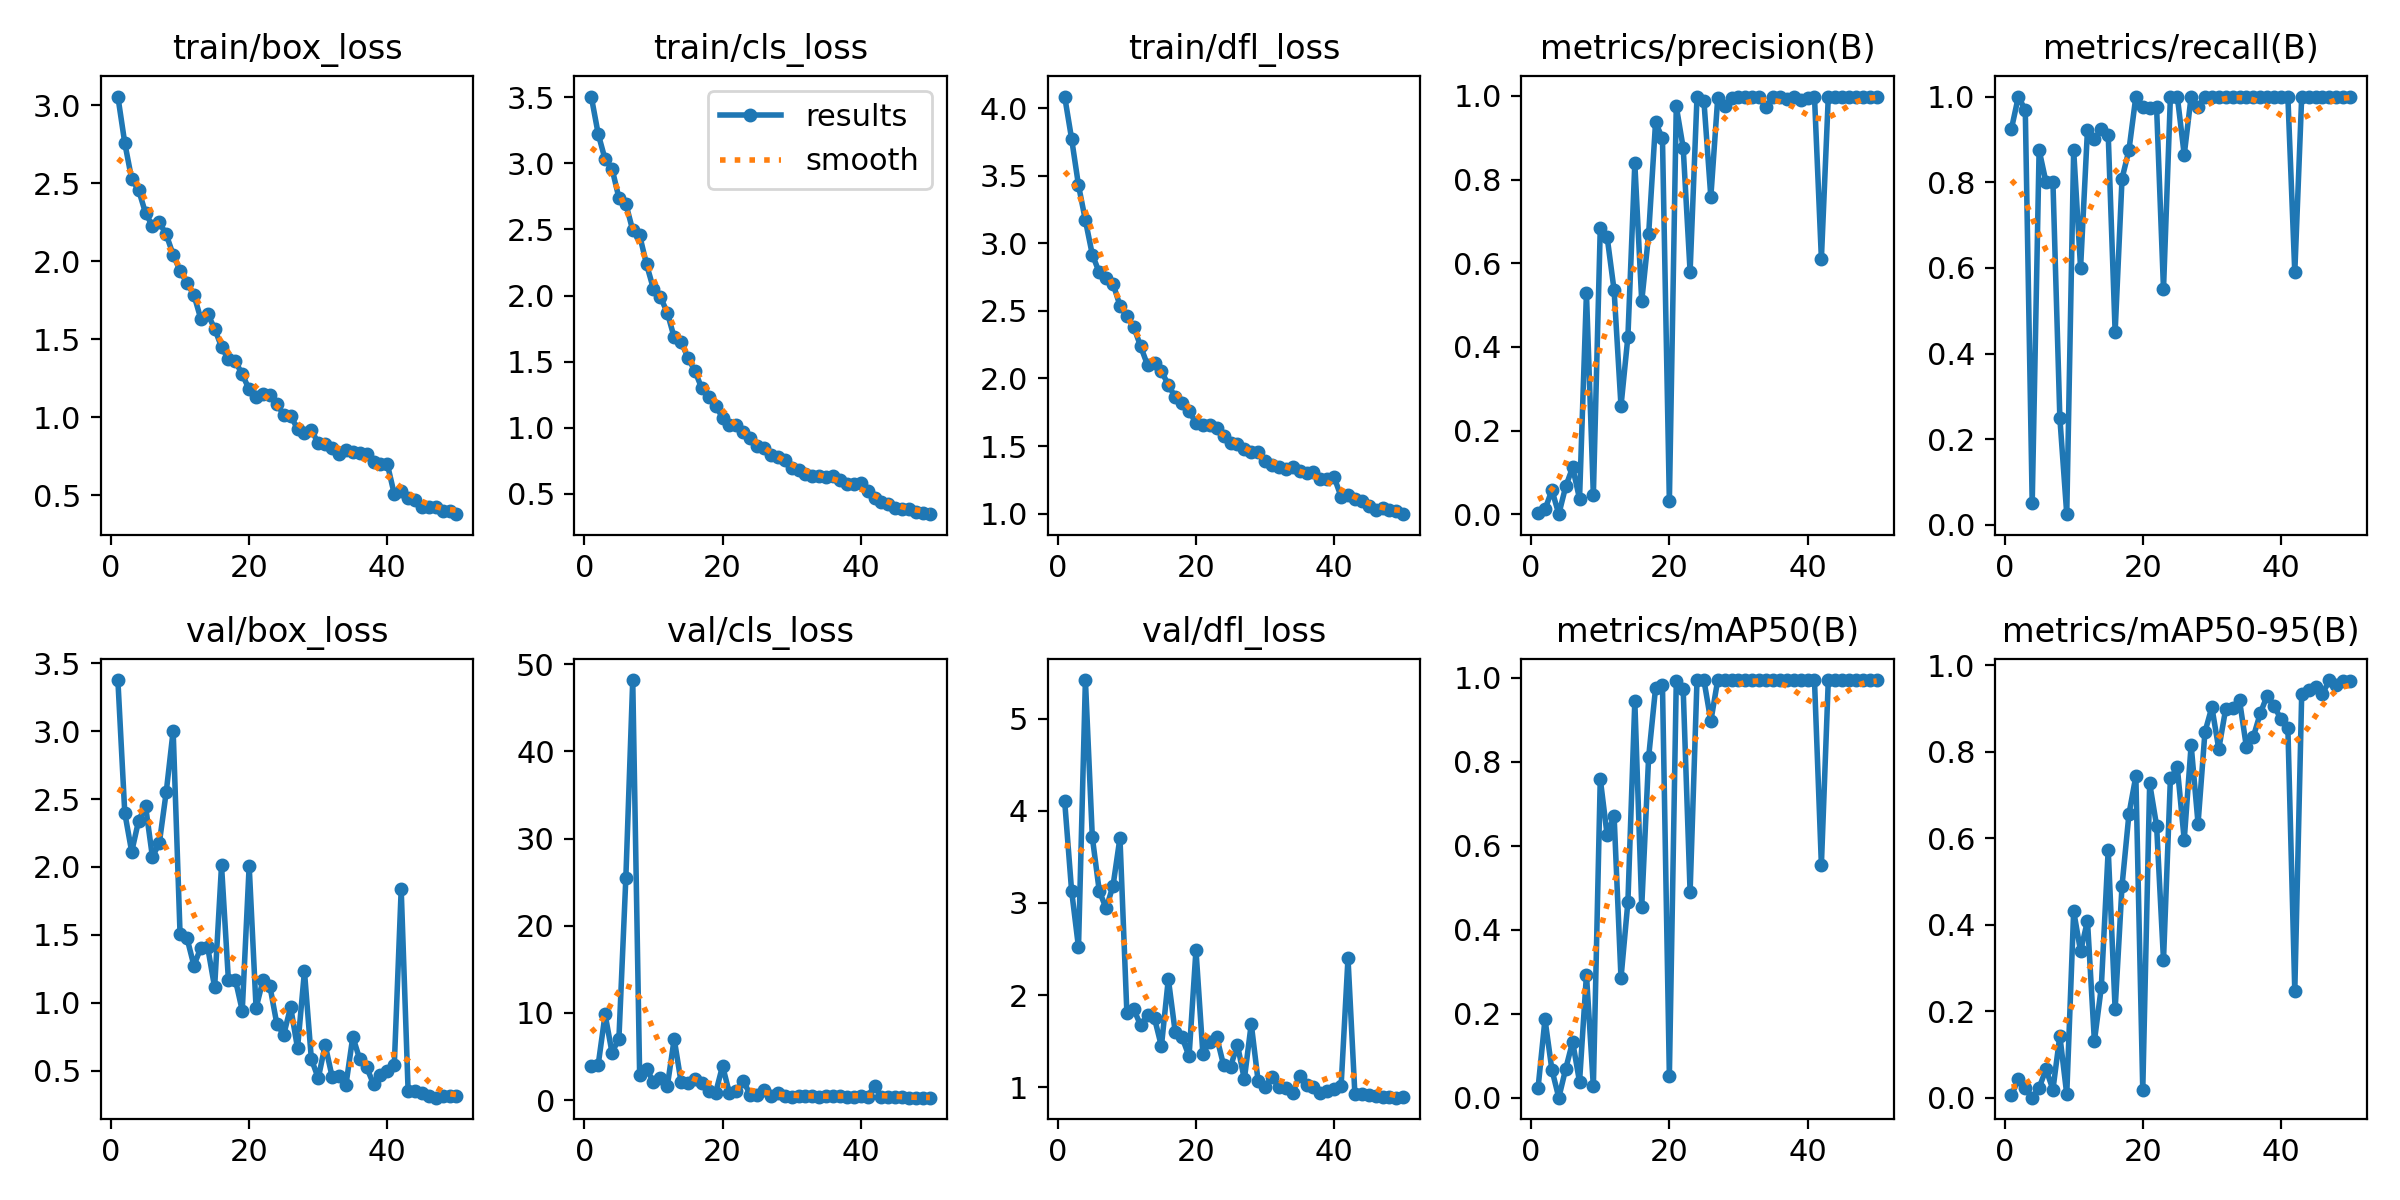

In [22]:
# We can also output some older school graphs if the tensor board isn't working for whatever reason...
Image(filename=f'{str(results.save_dir)}/results.png', width=1000)